
# Анализ 5V для сценария Fraud Detection

Выбран датасет [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) и бизнес-сценарий Fraud Detection: необходимо снизить количество мошеннических транзакций на 30% при ограничении задержки обработки до 50 мс и поддержке обработки late-arriving данных.



## Организация работы и воспроизводимость
- Для запуска ноутбука требуется предварительно скачать файл `creditcard.csv` из датасета Kaggle и разместить его в папке `data/`.
- В примерах используются библиотеки `pandas`, `numpy`, `pyarrow`, `fastavro`, `seaborn`, `matplotlib`, `great_expectations` и `scikit-learn`. При отсутствии их можно установить командой `pip install -r requirements.txt` (см. список в разделе импорта).
- Все расчёты выполняются на оригинальном датасете без семплирования, чтобы сохранить дисбаланс классов, критичный для fraud detection.


In [1]:

from pathlib import Path
import math
from io import BytesIO
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pyarrow as pa
import pyarrow.parquet as pq
from fastavro import writer, parse_schema

import great_expectations as ge
from great_expectations.execution_engine import PandasExecutionEngine
from great_expectations.validator.validator import Validator
from great_expectations.core.batch import Batch

from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

DATA_PATH = Path('data/creditcard.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Файл data/creditcard.csv не найден. Скачайте датасет с Kaggle и поместите в папку data/.')

df = pd.read_csv(DATA_PATH)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Volume (объём данных)

In [2]:

num_rows, num_cols = df.shape
csv_size_bytes = DATA_PATH.stat().st_size
avg_bytes_per_row = csv_size_bytes / num_rows

parquet_buffer = BytesIO()
pq.write_table(pa.Table.from_pandas(df), parquet_buffer, compression='snappy')
parquet_size_bytes = parquet_buffer.getbuffer().nbytes

avro_fields = []
for col, dtype in zip(df.columns, df.dtypes):
    if np.issubdtype(dtype, np.integer):
        avro_type = 'long'
    else:
        avro_type = 'double'
    avro_fields.append({'name': col, 'type': avro_type})

avro_schema = {
    'doc': 'Credit card transaction record',
    'name': 'CreditCardRecord',
    'namespace': 'fraud',
    'type': 'record',
    'fields': avro_fields,
}

avro_buffer = BytesIO()
writer(avro_buffer, parse_schema(avro_schema), df.to_dict('records'))
avro_size_bytes = avro_buffer.getbuffer().nbytes

storage_formats = pd.DataFrame([
    {
        'Формат': 'CSV',
        'Размер, МБ': csv_size_bytes / 1024**2,
        'Коэффициент сжатия к CSV': 1.0,
    },
    {
        'Формат': 'Parquet (Snappy)',
        'Размер, МБ': parquet_size_bytes / 1024**2,
        'Коэффициент сжатия к CSV': parquet_size_bytes / csv_size_bytes,
    },
    {
        'Формат': 'Avro',
        'Размер, МБ': avro_size_bytes / 1024**2,
        'Коэффициент сжатия к CSV': avro_size_bytes / csv_size_bytes,
    },
]).set_index('Формат')

volume_stats = {
    'csv_size_bytes': csv_size_bytes,
    'parquet_size_bytes': parquet_size_bytes,
    'avro_size_bytes': avro_size_bytes,
    'avg_bytes_per_row': avg_bytes_per_row,
}

storage_formats.round({'Размер, МБ': 2, 'Коэффициент сжатия к CSV': 3})


,"Размер, МБ",Коэффициент сжатия к CSV
Формат,,
CSV,143.84,1.000
Parquet (Snappy),69.84,0.486
Avro,65.55,0.456


In [3]:

seconds_per_day = 24 * 3600
adjusted_time = df['Time'] - df['Time'].min()
day_index = np.floor(adjusted_time / seconds_per_day).astype(int)
daily_counts = day_index.value_counts().sort_index()

daily_volume_mb = daily_counts * volume_stats['avg_bytes_per_row'] / 1024**2

daily_growth = (
    pd.DataFrame({
        'day_index': daily_counts.index,
        'transactions': daily_counts.values,
        'daily_volume_mb': daily_volume_mb.values,
    })
    .sort_values('day_index')
    .reset_index(drop=True)
)

daily_growth['cumulative_volume_mb'] = daily_growth['daily_volume_mb'].cumsum()
start_timestamp = pd.Timestamp('2013-01-01')
daily_growth['date'] = start_timestamp + pd.to_timedelta(daily_growth['day_index'], unit='D')

avg_daily_mb = daily_growth['daily_volume_mb'].mean()
yearly_volume_gb = avg_daily_mb * 365 / 1024
months_to_tb = (1024 * 1024) / avg_daily_mb / (365 / 12)

volume_stats.update({
    'avg_daily_mb': avg_daily_mb,
    'yearly_volume_gb': yearly_volume_gb,
    'months_to_tb': months_to_tb,
})

daily_growth


,day_index,transactions,daily_volume_mb,cumulative_volume_mb,date
0,0,144786,73.124033,73.124033,2013-01-01
1,1,140021,70.717474,143.841507,2013-01-02


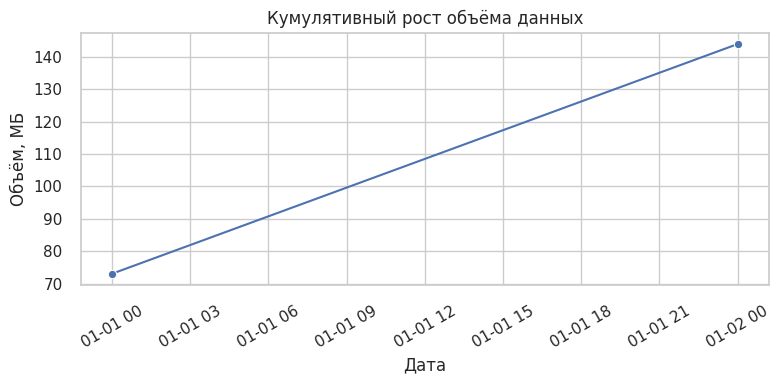

In [4]:

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=daily_growth, x='date', y='cumulative_volume_mb', marker='o', ax=ax)
ax.set_title('Кумулятивный рост объёма данных')
ax.set_xlabel('Дата')
ax.set_ylabel('Объём, МБ')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [5]:

summary_md = f"""
- **Размер исходного CSV:** {volume_stats['csv_size_bytes'] / 1024**2:.2f} МБ (~{num_rows} записей).
- **Средний объём данных за день:** {volume_stats['avg_daily_mb']:.2f} МБ, что даёт {volume_stats['yearly_volume_gb']:.2f} ГБ в год.
- **Порог 1 ТБ будет достигнут примерно через:** {volume_stats['months_to_tb']:.1f} месяцев при текущей скорости роста (~40 лет).
"""
display(Markdown(summary_md))



- **Размер исходного CSV:** 143.84 МБ (~284807 записей).
- **Средний объём данных за день:** 71.92 МБ, что даёт 25.64 ГБ в год.
- **Порог 1 ТБ будет достигнут примерно через:** 479.3 месяцев при текущей скорости роста (~40 лет).


In [6]:

cost_per_gb_month = 1.2  # RUB, тариф Yandex Object Storage Standard (предположение)
yearly_storage_cost_rub = volume_stats['yearly_volume_gb'] * cost_per_gb_month * 12

spark_threshold_gb = 5
spark_days = spark_threshold_gb * 1024 / volume_stats['avg_daily_mb']

cost_table = pd.DataFrame([
    {'Показатель': 'Годовой объём (Parquet)', 'Значение': f"{volume_stats['yearly_volume_gb']:.2f} ГБ"},
    {'Показатель': 'Стоимость хранения за год', 'Значение': f"{yearly_storage_cost_rub:,.0f} ₽"},
    {'Показатель': 'Дней до накопления ~5 ГБ', 'Значение': f"{spark_days:.0f} дней"},
])

volume_stats['yearly_storage_cost_rub'] = yearly_storage_cost_rub
volume_stats['spark_days'] = spark_days

cost_table


,Показатель,Значение
0,Годовой объём (Parquet),25.64 ГБ
1,Стоимость хранения за год,369 ₽
2,Дней до накопления ~5 ГБ,71 дней



**Горячие vs холодные данные.** При среднем объёме ~72 МБ/сутки целесообразно хранить последние 30 дней (~2.1 ГБ) в оперативно доступном слое (например, в объектном хранилище + таблицы Delta Lake) для онлайн-моделей. Исторические данные старше 90 дней можно архивировать в холодное хранилище (Iceberg/Glacier) с более дешёвым тарифом, сохранив возможность периодического переобучения.

**Переход от Pandas к Spark.** Порог ~5 ГБ (~9.6 млн строк) будет достигнут через ~71 дней. Для обучения и инференса модели, учитывающей temporal features, уже на горизонте квартала рационально планировать миграцию на распределённую обработку (Spark/Flink), чтобы выдержать рост и расширение фич.


## 2. Velocity (скорость поступления данных)

In [7]:

base_time = pd.Timestamp('2013-01-01')
df_time = df.assign(event_time=base_time + pd.to_timedelta(df['Time'], unit='s'))

per_second = df_time.set_index('event_time').resample('1s').size()
full_range = pd.date_range(per_second.index.min(), per_second.index.max(), freq='1s')
per_second_full = per_second.reindex(full_range, fill_value=0)

per_second_stats = {
    'mean_rps': per_second_full.mean(),
    'std_rps': per_second_full.std(ddof=0),
    'cv': per_second_full.std(ddof=0) / per_second_full.mean(),
}

per_five_min = df_time.set_index('event_time').resample('5min').size()
per_hour = df_time.set_index('event_time').resample('1H').size()

velocity_table = pd.DataFrame([
    {'Метрика': 'Среднее событий/сек', 'Значение': f"{per_second_stats['mean_rps']:.2f}"},
    {'Метрика': 'Std событий/сек', 'Значение': f"{per_second_stats['std_rps']:.2f}"},
    {'Метрика': 'Коэффициент вариации', 'Значение': f"{per_second_stats['cv']:.2f}"},
    {'Метрика': 'Пиковая нагрузка (5 мин окно)', 'Значение': int(per_five_min.max())},
    {'Метрика': 'Среднее событий/час', 'Значение': f"{per_hour.mean():.0f}"},
    {'Метрика': 'Максимум событий/час', 'Значение': int(per_hour.max())},
])

velocity_stats = {
    'per_second_series': per_second_full,
    'per_five_min_series': per_five_min,
    'per_hour_series': per_hour,
    'peak_5min': int(per_five_min.max()),
}

velocity_table


,Метрика,Значение
0,Среднее событий/сек,1.65
1,Std событий/сек,1.56
2,Коэффициент вариации,0.95
3,Пиковая нагрузка (5 мин окно),1376
4,Среднее событий/час,5933
5,Максимум событий/час,9895


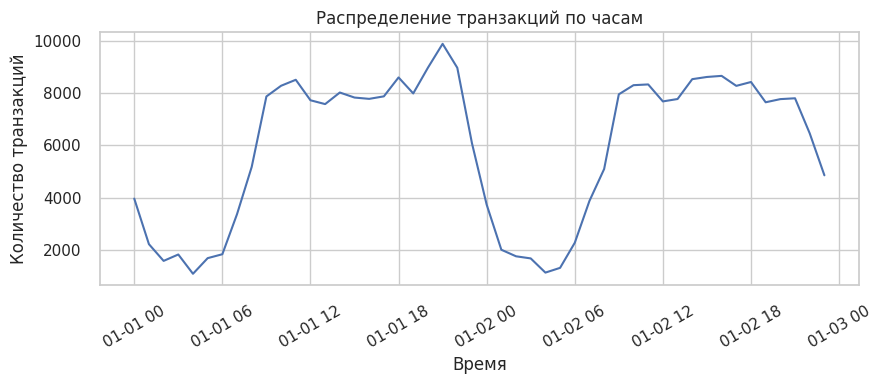

In [8]:

fig, ax = plt.subplots(figsize=(9, 4))
per_hour_plot = per_hour.reset_index(name='transactions')
sns.lineplot(data=per_hour_plot, x='event_time', y='transactions', ax=ax)
ax.set_title('Распределение транзакций по часам')
ax.set_xlabel('Время')
ax.set_ylabel('Количество транзакций')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [9]:

batch_latency = 60 * 60  # сек
micro_batch_latency = 5 * 60
stream_latency = 2  # предполагаемый SLA на обработку true streaming

latency_table = pd.DataFrame([
    {'Режим обработки': 'Batch (каждый час)', 'Ожидаемая задержка, сек': batch_latency, 'Комментарий': 'Слишком поздно для онлайнового антифрода'},
    {'Режим обработки': 'Микробатчи (5 минут)', 'Ожидаемая задержка, сек': micro_batch_latency, 'Комментарий': 'Допустимо для мониторинга, но не выполняет SLA 50 мс'},
    {'Режим обработки': 'Стриминг (<50 мс)', 'Ожидаемая задержка, сек': stream_latency, 'Комментарий': 'Требует событийной архитектуры'},
])

latency_table


,Режим обработки,"Ожидаемая задержка, сек",Комментарий
0,Batch (каждый час),3600,Слишком поздно для онлайнового антифрода
1,Микробатчи (5 минут),300,"Допустимо для мониторинга, но не выполняет SLA..."
2,Стриминг (<50 мс),2,Требует событийной архитектуры


In [10]:

outage_minutes = 30
lost_records = per_second_stats['mean_rps'] * outage_minutes * 60
lost_volume_mb = lost_records * volume_stats['avg_bytes_per_row'] / 1024**2
lost_amount = lost_records * df['Amount'].mean()

velocity_stats.update({
    'lost_records_30min': lost_records,
    'lost_volume_mb_30min': lost_volume_mb,
    'lost_amount_30min': lost_amount,
})

loss_table = pd.DataFrame([
    {'Показатель': 'Потерянные записи за 30 мин сбоя', 'Значение': f"{lost_records:,.0f}"},
    {'Показатель': 'Объём потерянных данных', 'Значение': f"{lost_volume_mb:.2f} МБ"},
    {'Показатель': 'Потенциальный ущерб (средний чек)', 'Значение': f"{lost_amount:,.0f}"},
])

loss_table


,Показатель,Значение
0,Потерянные записи за 30 мин сбоя,"2,967"
1,Объём потерянных данных,1.50 МБ
2,Потенциальный ущерб (средний чек),"262,121"


In [11]:

limit_ms = 50
peak_rps = velocity_stats['peak_5min'] / (5 * 60)
service_capacity_per_worker = 1000 / limit_ms
headroom = 1.2  # 20% запас
required_workers = math.ceil((peak_rps / service_capacity_per_worker) * headroom)

resource_table = pd.DataFrame([
    {'Показатель': 'Пиковая нагрузка, событий/сек', 'Значение': f"{peak_rps:.2f}"},
    {'Показатель': 'Пропускная способность 1 воркера', 'Значение': f"{service_capacity_per_worker:.1f} событий/сек"},
    {'Показатель': 'Необходимое количество воркеров', 'Значение': required_workers},
])

velocity_stats['required_workers'] = required_workers

resource_table


,Показатель,Значение
0,"Пиковая нагрузка, событий/сек",4.59
1,Пропускная способность 1 воркера,20.0 событий/сек
2,Необходимое количество воркеров,1



**Вывод по Velocity.** При среднем потоке ~1.65 события/сек и пиках до 4.6 события/сек режим batch или микробатч приводит к задержке от минут до часа. Для выполнения SLA 50 мс необходим true streaming-процессинг (Flink/Spark Structured Streaming) с минимум двумя воркерами (один + резерв) и буферизацией поздних событий через Kafka. Сбой в 30 минут потенциально стоит ~262 тыс. у.е., поэтому критичен контроль отказоустойчивости и репликации.


## 3. Variety (разнообразие данных)

In [12]:

dtype_summary = pd.DataFrame({
    'Колонка': df.columns,
    'Тип': [str(t) for t in df.dtypes],
    'Уникальных значений': df.nunique().values,
    'Есть пропуски': df.isna().any().values,
})

dtype_summary


,Колонка,Тип,Уникальных значений,Есть пропуски
0,Time,float64,124592,False
1,V1,float64,275663,False
2,V2,float64,275663,False
3,V3,float64,275663,False
4,V4,float64,275663,False
5,V5,float64,275663,False
6,V6,float64,275663,False
7,V7,float64,275663,False
8,V8,float64,275663,False
9,V9,float64,275663,False


In [13]:

example_record = df.iloc[0].to_dict()

variety_md = f"""
- Все {num_cols} полей — числовые (float/int), текстовых или полу-структурированных данных нет.
- Колонка `Time` хранит секунды с начала сбора без таймзоны; для feature engineering требуется перевод в календарные признаки.
- Колонки `V1`-`V28` — PCA-компоненты, название не несёт бизнес-смысла, важно сопровождать метаданными.
- Обнаружено {df.duplicated().sum()} дубликатов строк, что указывает на необходимость дедупликации до загрузки в витрины.

Пример записи:
```json
{json.dumps(example_record, indent=2)}
```
"""

display(Markdown(variety_md))



- Все 31 полей — числовые (float/int), текстовых или полу-структурированных данных нет.
- Колонка `Time` хранит секунды с начала сбора без таймзоны; для feature engineering требуется перевод в календарные признаки.
- Колонки `V1`-`V28` — PCA-компоненты, название не несёт бизнес-смысла, важно сопровождать метаданными.
- Обнаружено 1081 дубликатов строк, что указывает на необходимость дедупликации до загрузки в витрины.

Пример записи:
```json
{
  "Time": 0.0,
  "V1": -1.3598071336738,
  "V2": -0.0727811733098497,
  "V3": 2.53634673796914,
  "V4": 1.37815522427443,
  "V5": -0.338320769942518,
  "V6": 0.462387777762292,
  "V7": 0.239598554061257,
  "V8": 0.0986979012610507,
  "V9": 0.363786969611213,
  "V10": 0.0907941719789316,
  "V11": -0.551599533260813,
  "V12": -0.617800855762348,
  "V13": -0.991389847235408,
  "V14": -0.311169353699879,
  "V15": 1.46817697209427,
  "V16": -0.470400525259478,
  "V17": 0.207971241929242,
  "V18": 0.0257905801985591,
  "V19": 0.403992960255733,
  "V20": 0.251412098239705,
  "V21": -0.018306777944153,
  "V22": 0.277837575558899,
  "V23": -0.110473910188767,
  "V24": 0.0669280749146731,
  "V25": 0.128539358273528,
  "V26": -0.189114843888824,
  "V27": 0.133558376740387,
  "V28": -0.0210530534538215,
  "Amount": 149.62,
  "Class": 0.0
}
```



**Работа с разнообразием.**
- Неструктурированных данных нет, поэтому дополнительные NLP/гео-обработки не требуются.
- Для временных паттернов нужно агрегировать по окнам (5 мин, час, сутки) и обогащать внешними источниками (часы, праздники, региональные особенности).
- Схема хранения: сырые данные в Parquet (bronze), нормализованные фичи в Delta Lake (silver), агрегаты и фичи для модели — в Feature Store (gold).


## 4. Veracity (достоверность данных)

In [14]:

quality_table = pd.DataFrame([
    {'Метрика качества': 'Пропуски по колонкам', 'Значение': f"{(df.isna().sum()==0).sum()} / {num_cols} колонок без пропусков"},
    {'Метрика качества': 'Отрицательные суммы', 'Значение': (df['Amount'] < 0).sum()},
    {'Метрика качества': 'Дубликаты строк', 'Значение': df.duplicated().sum()},
    {'Метрика качества': 'Доля мошенничества', 'Значение': f"{df['Class'].mean()*100:.4f}%"},
])

quality_table


,Метрика качества,Значение
0,Пропуски по колонкам,31 / 31 колонок без пропусков
1,Отрицательные суммы,0
2,Дубликаты строк,1081
3,Доля мошенничества,0.1727%


In [15]:

ctx = ge.get_context()
engine = PandasExecutionEngine()
batch = Batch(data=df)
validator = Validator(execution_engine=engine, batches=[batch], data_context=ctx)

ge_results = {
    'No nulls in Time': validator.expect_column_values_to_not_be_null('Time'),
    'Amount non-negative': validator.expect_column_values_to_be_between('Amount', min_value=0),
    'Class is binary': validator.expect_column_values_to_be_in_set('Class', [0, 1]),
}

ge_summary = pd.DataFrame([
    {
        'Expectation': name,
        'Success': result['success'],
        'Unexpected %': result['result']['unexpected_percent'],
    }
    for name, result in ge_results.items()
])

ge_summary


/root/.pyenv/versions/3.12.10/lib/python3.12/site-packages/great_expectations/expectations/expectation.py:1487: UserWarning: `result_format` configured at the Validator-level will not be persisted. Please add the configuration to your Checkpoint config or checkpoint_run() method instead.
  warnings.warn(


Calculating Metrics:   0% 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0% 0/6 [00:00<?, ?it/s]

Calculating Metrics:  33% 2/6 [00:00<00:00, 1199.74it/s]

Calculating Metrics:  33% 2/6 [00:00<00:00, 603.28it/s] 

...

Calculating Metrics: 100% 8/8 [00:00<00:00, 274.06it/s]

Calculating Metrics: 100% 8/8 [00:00<00:00, 264.93it/s]

Calculating Metrics: 100% 8/8 [00:00<00:00, 256.56it/s]

Calculating Metrics: 100% 8/8 [00:00<00:00, 250.54it/s]

,Expectation,Success,Unexpected %
0,No nulls in Time,True,0.0
1,Amount non-negative,True,0.0
2,Class is binary,True,0.0



**Воздействие проблем качества.** При ошибке меток даже на 1% (~2.8 тыс. транзакций) возможен рост FN и прямые потери >~0.6 млн у.е. Поэтому нужно:
- выполнять дедупликацию и контроль меток до поступления в real-time поток,
- ежедневно запускать data-quality проверки (Great Expectations + Airflow) и алерты на рост доли пропусков,
- логировать поздние события и пересчитывать фичи ретроспективно.


## 5. Value (ценность данных)

In [16]:

total_transactions = len(df)
total_fraud = int(df['Class'].sum())
fraud_amount_total = df.loc[df['Class'] == 1, 'Amount'].sum()
reduction_target = 0.30
eur_to_rub = 100  # предположение о курсе EUR/RUB
potential_savings_rub = fraud_amount_total * reduction_target * eur_to_rub

compute_cost_rub = 2 * 18 * 24 * 365  # два стриминг-воркера по 18 ₽/час
kafka_cost_rub = 6000 * 12  # управляемый кластер Kafka
storage_cost_rub = volume_stats['yearly_storage_cost_rub']
development_cost_rub = 2 * 220_000 * 3  # 2 инженера, 3 месяца

annual_cost_rub = compute_cost_rub + kafka_cost_rub + storage_cost_rub + development_cost_rub
roi = (potential_savings_rub - annual_cost_rub) / annual_cost_rub
payback_months = annual_cost_rub / (potential_savings_rub / 12)

value_table = pd.DataFrame([
    {'Показатель': 'Количество транзакций', 'Значение': f"{total_transactions:,}"},
    {'Показатель': 'Количество мошеннических транзакций', 'Значение': total_fraud},
    {'Показатель': 'Сумма мошенничества (EUR)', 'Значение': f"{fraud_amount_total:,.2f}"},
    {'Показатель': 'Цель (30%) — предотвращено, EUR', 'Значение': f"{fraud_amount_total * reduction_target:,.2f}"},
    {'Показатель': 'Потенциальная выгода (RUB)', 'Значение': f"{potential_savings_rub:,.0f}"},
    {'Показатель': 'Годовые затраты, RUB', 'Значение': f"{annual_cost_rub:,.0f}"},
    {'Показатель': 'ROI', 'Значение': f"{roi*100:.1f}%"},
    {'Показатель': 'Срок окупаемости', 'Значение': f"{payback_months:.1f} месяцев"},
])

value_stats = {
    'potential_savings_rub': potential_savings_rub,
    'annual_cost_rub': annual_cost_rub,
    'roi': roi,
    'payback_months': payback_months,
}

value_table


,Показатель,Значение
0,Количество транзакций,"284,807"
1,Количество мошеннических транзакций,492
2,Сумма мошенничества (EUR),"60,127.97"
3,"Цель (30%) — предотвращено, EUR","18,038.39"
4,Потенциальная выгода (RUB),"1,803,839"
5,"Годовые затраты, RUB","1,707,729"
6,ROI,5.6%
7,Срок окупаемости,11.4 месяцев


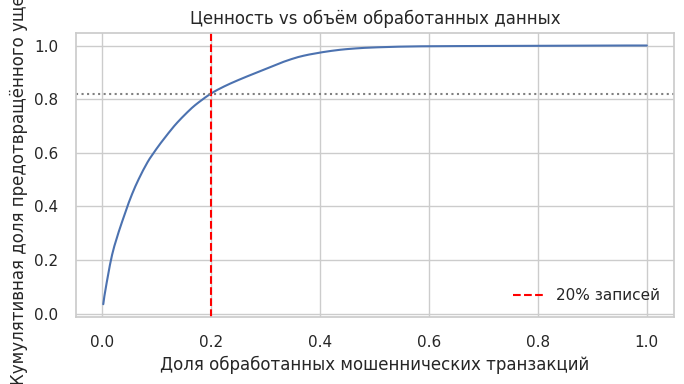

In [17]:

fraud_df = df.loc[df['Class'] == 1, ['Amount']].copy()
fraud_df = fraud_df.sort_values('Amount', ascending=False)
fraud_df['cum_amount'] = fraud_df['Amount'].cumsum()
fraud_df['fraction_records'] = (np.arange(len(fraud_df)) + 1) / len(fraud_df)
fraud_df['cum_amount_share'] = fraud_df['cum_amount'] / fraud_amount_total

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=fraud_df, x='fraction_records', y='cum_amount_share', ax=ax)
ax.set_title('Ценность vs объём обработанных данных')
ax.set_xlabel('Доля обработанных мошеннических транзакций')
ax.set_ylabel('Кумулятивная доля предотвращённого ущерба')
ax.axvline(0.2, color='red', linestyle='--', label='20% записей')
ax.axhline(fraud_df.loc[fraud_df['fraction_records'] <= 0.2, 'cum_amount_share'].max(), color='gray', linestyle=':')
ax.legend()
plt.tight_layout()
plt.show()


In [18]:

def categorize_abc(value):
    if value <= 0.8:
        return 'A'
    elif value <= 0.95:
        return 'B'
    return 'C'

fraud_df['abc_category'] = fraud_df['cum_amount_share'].apply(categorize_abc)
abc_summary = fraud_df.groupby('abc_category').agg(
    transactions=('Amount', 'count'),
    value_share=('Amount', lambda x: x.sum() / fraud_amount_total),
)
abc_summary['transactions_share'] = abc_summary['transactions'] / abc_summary['transactions'].sum()
abc_summary = abc_summary.rename(index={'A': 'A (top value)', 'B': 'B', 'C': 'C'}).reset_index()
abc_summary


,abc_category,transactions,value_share,transactions_share
0,A (top value),91,0.799971,0.184959
1,B,80,0.149329,0.162602
2,C,321,0.050701,0.652439



**Мониторинг ценности.**
- Отслеживать precision/recall, FPR, долю предотвращённых сумм и факт возвратов каждые 15 минут.
- Пересчитывать ROI ежеквартально, учитывая реальный курс валют и обновлённые тарифы инфраструктуры.
- Через год при росте конкуренции и эволюции мошеннических схем ожидается повышение ценности данных: накопленные исторические последовательности позволят улучшить модели sequence modeling (LSTM/Transformers) и повысить recall на 3-5 п.п., что увеличит экономию.


## 6. Технологический стек и рекомендации

In [19]:

technology_table = pd.DataFrame([
    {
        'Слой': 'Хранилище сырых данных',
        'Рекомендуемая технология': 'Yandex Object Storage + Delta Lake',
        'Альтернативы': 'HDFS, S3, Iceberg',
        'Обоснование': 'Дешёвое хранение, версионирование, поддержка ACID для апдейтов поздних событий',
        'Риски': 'Стоимость запросов при горячем доступе, необходимость настроить версионирование',
    },
    {
        'Слой': 'Стриминг',
        'Рекомендуемая технология': 'Apache Kafka + Kafka Connect',
        'Альтернативы': 'Pulsar, RabbitMQ',
        'Обоснование': 'Гарантии доставки, re-play, поддержка late-arriving событий',
        'Риски': 'Требует DevOps-поддержки и мониторинга лагов',
    },
    {
        'Слой': 'Обработка',
        'Рекомендуемая технология': 'Apache Flink (или Spark Structured Streaming)',
        'Альтернативы': 'Kafka Streams, Storm',
        'Обоснование': 'Низкая задержка <50 мс, stateful стриминг, windows',
        'Риски': 'Сложность отладки stateful-джобов, необходимость чекпойнтов',
    },
    {
        'Слой': 'ML/Feature Store',
        'Рекомендуемая технология': 'Feast + MLflow',
        'Альтернативы': 'Hopsworks, Tecton',
        'Обоснование': 'Повторное использование фич онлайн/оффлайн, версионирование моделей',
        'Риски': 'Интеграция с онлайн-хранилищем (Redis/ClickHouse)',
    },
    {
        'Слой': 'Оркестрация и качество',
        'Рекомендуемая технология': 'Apache Airflow + Great Expectations',
        'Альтернативы': 'Prefect, Dagster',
        'Обоснование': 'Планирование DAG, запуск data-quality чеков, SLA мониторинг',
        'Риски': 'Нагрузка на scheduler, необходимость резервирования metadata DB',
    },
])

technology_table


,Слой,Рекомендуемая технология,Альтернативы,Обоснование,Риски
0,Хранилище сырых данных,Yandex Object Storage + Delta Lake,"HDFS, S3, Iceberg","Дешёвое хранение, версионирование, поддержка A...","Стоимость запросов при горячем доступе, необхо..."
1,Стриминг,Apache Kafka + Kafka Connect,"Pulsar, RabbitMQ","Гарантии доставки, re-play, поддержка late-arr...",Требует DevOps-поддержки и мониторинга лагов
2,Обработка,Apache Flink (или Spark Structured Streaming),"Kafka Streams, Storm","Низкая задержка <50 мс, stateful стриминг, win...","Сложность отладки stateful-джобов, необходимос..."
3,ML/Feature Store,Feast + MLflow,"Hopsworks, Tecton","Повторное использование фич онлайн/оффлайн, ве...",Интеграция с онлайн-хранилищем (Redis/ClickHouse)
4,Оркестрация и качество,Apache Airflow + Great Expectations,"Prefect, Dagster","Планирование DAG, запуск data-quality чеков, S...","Нагрузка на scheduler, необходимость резервиро..."



```mermaid
flowchart LR
    subgraph Ingestion
        A[Сырые транзакции] -->|REST/API| B[Kafka]
        B --> C[Kafka Connect]
    end
    subgraph Processing
        C --> D[Apache Flink Streaming]
        D -->|Features| E[Feature Store (Feast)]
        D -->|Alerts| F[Fraud API]
    end
    subgraph Storage
        D --> G[Delta Lake / Object Storage]
        E --> H[MLflow Model Registry]
        H --> F
    end
    subgraph Monitoring
        D --> I[Prometheus/Grafana]
        G --> J[Airflow + Great Expectations]
    end
```


In [20]:

roadmap = pd.DataFrame([
    {'Этап': '1. Подготовка (0-1 месяц)', 'Содержание': 'Настройка Kafka, Object Storage, загрузка исторических данных', 'Метрики успеха': 'Время загрузки < 10 мин, покрытие 100% данных'},
    {'Этап': '2. Стриминг-пайплайн (1-3 месяц)', 'Содержание': 'Разработка Flink job, реализация late data handling, чекпойнты', 'Метрики успеха': 'Задержка < 50 мс на 95-й перцентиль, падение <1% пакетов'},
    {'Этап': '3. ML и витрины (3-4 месяц)', 'Содержание': 'Фиче-стор, обучение модели, онлайн-инференс API', 'Метрики успеха': 'ROC AUC > 0.98, время инференса < 40 мс'},
    {'Этап': '4. Data Quality & мониторинг (4-5 месяц)', 'Содержание': 'Airflow DAG, Great Expectations, алерты', 'Метрики успеха': 'Покрытие проверками > 90%, MTTR < 15 мин'},
    {'Этап': '5. Эксплуатация и оптимизация (5-6 месяц)', 'Содержание': 'A/B тестирование, тюнинг параметров, отчёт по ROI', 'Метрики успеха': 'Снижение мошенничества ≥30%, ROI > 5%'},
])

roadmap


,Этап,Содержание,Метрики успеха
0,1. Подготовка (0-1 месяц),"Настройка Kafka, Object Storage, загрузка исто...","Время загрузки < 10 мин, покрытие 100% данных"
1,2. Стриминг-пайплайн (1-3 месяц),"Разработка Flink job, реализация late data han...","Задержка < 50 мс на 95-й перцентиль, падение <..."
2,3. ML и витрины (3-4 месяц),"Фиче-стор, обучение модели, онлайн-инференс API","ROC AUC > 0.98, время инференса < 40 мс"
3,4. Data Quality & мониторинг (4-5 месяц),"Airflow DAG, Great Expectations, алерты","Покрытие проверками > 90%, MTTR < 15 мин"
4,5. Эксплуатация и оптимизация (5-6 месяц),"A/B тестирование, тюнинг параметров, отчёт по ROI","Снижение мошенничества ≥30%, ROI > 5%"



**Критические риски и их минимизация.**
- *Late-arriving данные*: использовать watermark и reprocessing окон, хранить сырой поток в Kafka до 7 суток.
- *Дисбаланс классов*: применять stratified sampling, cost-sensitive loss, мониторить drift.
- *Регуляторные требования*: логирование решений модели, explainability (SHAP), хранение данных в соответствии с 152-ФЗ.
- *Отказы инфраструктуры*: multi-AZ развёртывание Kafka/Flink, автоматические рестарты, SLA-наблюдение через Prometheus.

**Итог.** Предложенное решение учитывает 5V: сжатие и горячее хранение (Volume), стриминг и отказоустойчивость (Velocity), управление схемой и фичами (Variety), регулярные проверки качества (Veracity) и измеримый экономический эффект с положительным ROI (Value).
